# NEMI on fronts

Clusters fronts rather than patches.  The cutout pipeline turns images into
vectors before it can cluster them; a front is already a row of numbers, so the
CNN trunk and the patch machinery drop out and `fronts_dataloader` hands NEMI a
matrix directly.

This notebook loads the small finding run — three SURF snapshots — and
assembles the feature matrix.  See `docs/fronts_dataloader.md` for the
selection and scaling contract.

## The store

In [1]:
import numpy as np
import pandas as pd

from fronts_dataloader.fronts_dataset import FrontDataSource, RawFronts

#: The small finding run, where build-fronts' push step publishes it.  The key
#: is assembled from the run config's source block, so the products sit beside
#: the stores they were derived from:
#:     {bucket}/{folder}/{run_id}/Fronts/{build_version}/{pipeline}/fronts.zarr
STORE = ("s3://dbof/globals_for_cutouts/v2_2_01"
         "/Fronts/SMALL_DATASET/SURF/fronts.zarr")

#: Nautilus, not AWS, so the endpoint has to be given explicitly.
S3_ENDPOINT = "https://s3-west.nrp-nautilus.io"

source = FrontDataSource(STORE, storage_options={"endpoint_url": S3_ENDPOINT})
print(f"{len(source.dates)} snapshots")
print(source.store.status().to_string(index=False))

3 snapshots
           date find group colocate
20111216_030000 done  done     done
20120104_110000 done  done     done
20120208_230000 done  done     done


What `colocate` recorded decides what the features mean: which
statistics exist at all, how wide a band each was measured over, and whether
land was dropped or propagated.

In [2]:
# What the colocate step recorded -- these decide what the features mean.
attrs = source.store.step_attrs(source.dates[0], "colocate")
for key in ("stats", "percentiles", "properties_dilation_radius",
            "properties_cross_front_radius", "dilate_only_to_front_pixels",
            "min_npix", "nan_policy"):
    print(f"  {key:30s} {attrs.get(key, '(absent)')}")

for group, columns in source.feature_groups().items():
    print(f"\n{group}  ({len(columns)} columns)")
    print("   ", ", ".join(columns[:8]), "..." if len(columns) > 8 else "")

  stats                          ['mean', 'std', 'min', 'max', 'skew']
  percentiles                    [25, 75, 90]
  properties_dilation_radius     2
  properties_cross_front_radius  0
  dilate_only_to_front_pixels    True
  min_npix                       1
  nan_policy                     omit

geometry  (12 columns)
    npix, centroid_lat, centroid_lon, length_km, orientation, num_branches, lat_min, lat_max ...

properties  (241 columns)
    npix, gradb2_mean, gradb2_std, gradb2_min, gradb2_max, gradb2_skew, gradb2_p25, gradb2_p75 ...


## Load

Every snapshot, one row per front.  Load once and `select` repeatedly — the load is the expensive half.

In [4]:
raw = RawFronts.load(source)

print(f"{len(raw):,} fronts over {len(source.dates)} snapshots")
print(raw.table.groupby("date").size().rename("fronts").to_string())

378,697 fronts over 3 snapshots
date
20111216_030000    127627
20120104_110000    127634
20120208_230000    123436


## Select features

`select` takes groups (`geometry`, `properties`, `cross`), channels
(`gradb2`, which expands to each of its statistics), or single columns, mixed
in one list.

`nan_policy="fill"` keeps every front and every feature.  `fill_value="mean"`
puts an unmeasured front at its column's centre, which asserts nothing; the
`_missing` indicator columns keep a filled value distinguishable from a
measured one.

In [5]:
FEATURES = ["mean_curvature", "length_km", "orientation", "num_branches", "curvature_direction",
            "gradb2", "Theta", "Eta", "density", "gradeta2", "oceQnet", "okubo_weiss",
            "rossby_number", "strain_mag", "strain_s", "strain_n", "wind_stress_curl"]

ds = raw.select(FEATURES, stats=("mean", "std", "skew"), scaling="standardize", nan_policy="fill", div_by_f=True,
                fill_value="mean", missing_indicator=False)
print(ds.summary())



# FEATURES = ["turner_angle"]

# ds = raw.select(FEATURES, stats=("mean", "std", "skew"), scaling="standardize", nan_policy="fill", div_by_f=True,
#                 fill_value="mean", missing_indicator=False)
# print(ds.summary())


# A column filled for most fronts describes the fill, not the ocean.
print("\nmost-filled columns:")
for column, info in ds.worst_filled()[:8]:
    print(f"  {column:30s} {info['n']:8,d}  {100 * info['n'] / len(ds):5.1f}%")

ds.summary()


378,697 fronts x 41 features  scaling=standardize  filled 22 columns (worst mean_curvature 20%)  divided 6 by |f|

most-filled columns:
  mean_curvature                   74,809   19.8%
  curvature_direction              74,809   19.8%
  gradeta2_skew                    38,416   10.1%
  gradb2_skew                      24,810    6.6%
  okubo_weiss_skew                    201    0.1%
  rossby_number_skew                  201    0.1%
  strain_mag_skew                     201    0.1%
  strain_s_skew                       201    0.1%


'378,697 fronts x 41 features  scaling=standardize  filled 22 columns (worst mean_curvature 20%)  divided 6 by |f|'

`mean_curvature` is missing for 20%, and that is not "this front is straight".
The estimator needs a skeleton longer than `2 * window_size = 10` px, so every
short front comes back undefined.  Straight is measurable and comes out near
zero.

## The matrix

`X` is what `nemi.run` takes; `ids` are the same rows in the same order, so a cluster label joins back to the store on `(date, label)`.

In [6]:
print("X", ds.X.shape, ds.X.dtype, " finite:", bool(np.isfinite(ds.X).all()))
ds.to_frame().head()

#ds.to_frame().shape

#NOTE the first 4 are not included in clustering

X (378697, 41) float32  finite: True


,date,label,name,time,mean_curvature,length_km,orientation,num_branches,curvature_direction,gradb2_mean,...,strain_mag_skew,strain_s_mean,strain_s_std,strain_s_skew,strain_n_mean,strain_n_std,strain_n_skew,wind_stress_curl_mean,wind_stress_curl_std,wind_stress_curl_skew
0,20111216_030000,7657,20111216TT030000_69.5S_148.5W,2011-12-16T03:00:00,-4.370806e-01,-0.538221,0.290128,-0.262558,-5.103524e-01,-1.045179,...,-0.163350,-0.230493,-0.679366,-1.161607,-0.105056,-0.701498,-0.260768,-0.487116,0.195111,-0.480537
1,20111216_030000,7658,20111216TT030000_69.5S_133.6W,2011-12-16T03:00:00,1.149799e+00,-0.490311,1.450387,-0.262558,6.121740e-01,0.183993,...,-0.319290,-0.022635,-0.712679,-0.380164,0.085358,-0.721625,-0.570037,0.043069,-0.025781,-1.288399
2,20111216_030000,7659,20111216TT030000_69.4S_125.7W,2011-12-16T03:00:00,-6.368697e-01,-0.486777,-0.614486,-0.262558,-1.807210e-01,-0.357196,...,-1.437173,-0.000966,-0.682039,-0.092246,-0.035549,-0.677804,1.264370,0.198545,-0.028887,0.227837
3,20111216_030000,7660,20111216TT030000_69.5S_101.6W,2011-12-16T03:00:00,1.174528e-16,-0.562373,0.946706,-0.262558,-3.654564e-18,0.069027,...,0.011816,-0.140123,-0.671737,1.111145,0.011231,-0.705658,0.789523,0.209510,-0.083539,2.317158
4,20111216_030000,7661,20111216TT030000_69.5S_50.6W,2011-12-16T03:00:00,1.174528e-16,-0.566558,1.070999,-0.262558,-3.654564e-18,1.274694,...,-0.818595,-0.122375,-0.730238,0.283594,-0.024943,-0.730445,1.188787,-0.056378,-0.096086,-0.640167


## Sweep

`run_sweep` takes the two NEMI dictionaries as grids and expands them
full-factorially.  Each embedding is fitted once and reused for every
clustering configuration on top of it, so the cost is the size of the embedding
grid, not the product of the two.

`fit_size` subsamples before fitting -- a full UMAP per cell is not what you
want while choosing parameters.

In [7]:
from nemi_sweep.sweep import run_sweep
from visualization.sweep_plots import (plot_all_metric_heatmaps,
                                       plot_embedding_grid)

EMBEDDING_GRID = {"n_neighbors": [5, 50, 100, 150, 200], "min_dist": [0.0, 0.05]}
#CLUSTERING_GRID = {"method": ["dbscan"], "eps": [0.05, 0.1, 0.5], "min_samples": [5, 10, 50, 100]}

result = run_sweep(ds.X, EMBEDDING_GRID, #CLUSTERING_GRID,
                   n_components=3, device="gpu",
                   fit_size=50_000, metric_sample=3_000, keep_size=30_000)


/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


embedding {'n_neighbors': 5, 'min_dist': 0.0}
   trustworthiness=0.850  continuity=0.905  normalized_stress=0.288
embedding {'n_neighbors': 5, 'min_dist': 0.05}
[2026-09-21 17:10:46.007] [CUML] [info] Building knn graph using brute force
   trustworthiness=0.850  continuity=0.913  normalized_stress=0.243
embedding {'n_neighbors': 50, 'min_dist': 0.0}
[2026-09-21 17:10:47.247] [CUML] [info] Building knn graph using brute force
   trustworthiness=0.857  continuity=0.932  normalized_stress=0.288
embedding {'n_neighbors': 50, 'min_dist': 0.05}
[2026-09-21 17:10:48.750] [CUML] [info] Building knn graph using brute force
   trustworthiness=0.856  continuity=0.934  normalized_stress=0.258
embedding {'n_neighbors': 100, 'min_dist': 0.0}
[2026-09-21 17:10:50.199] [CUML] [info] Building knn graph using brute force
   trustworthiness=0.856  continuity=0.934  normalized_stress=0.275
embedding {'n_neighbors': 100, 'min_dist': 0.05}
[2026-09-21 17:10:52.293] [CUML] [info] Building knn graph using br

In [8]:
print(result.summary())

10 configurations  10 embeddings fitted  swept n_neighbors, min_dist


One row per (embedding x clustering) configuration, parameters beside metrics.  `normalized_stress` and `noise_%` read lower-is-better; the rest higher.

In [9]:
result.table.sort_values("trustworthiness", ascending=False)

,n_neighbors,min_dist,trustworthiness,continuity,normalized_stress
2,50,0.00,0.856677,0.932434,0.288428
4,100,0.00,0.856338,0.933950,0.274523
5,100,0.05,0.855888,0.936003,0.257321
3,50,0.05,0.855778,0.934222,0.257829
6,150,0.00,0.854717,0.933693,0.280017
8,200,0.00,0.854142,0.933905,0.272958
9,200,0.05,0.852772,0.935891,0.254305
7,150,0.05,0.851469,0.935912,0.255059
0,5,0.00,0.850024,0.904875,0.287965
1,5,0.05,0.849706,0.913266,0.243161


## Plot

Both put the same two swept parameters on the same axes, so a heatmap cell and the scatter beneath it are the same configuration.

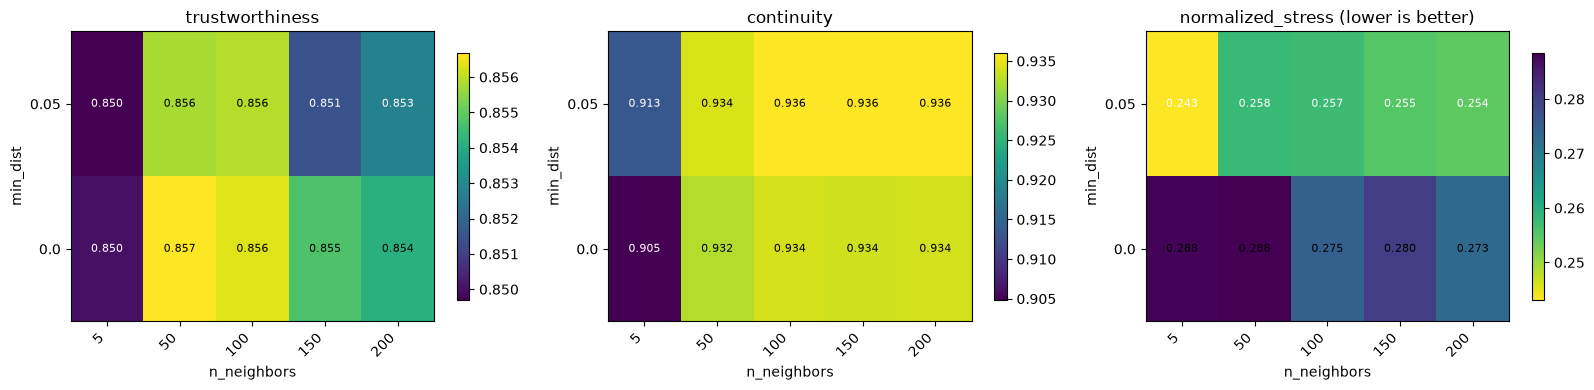

In [10]:
plot_all_metric_heatmaps(result, x="n_neighbors", y="min_dist");

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/visualization/sweep_plots.py:155: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(*[E[:, d] for d in range(min(dims, E.shape[1]))],


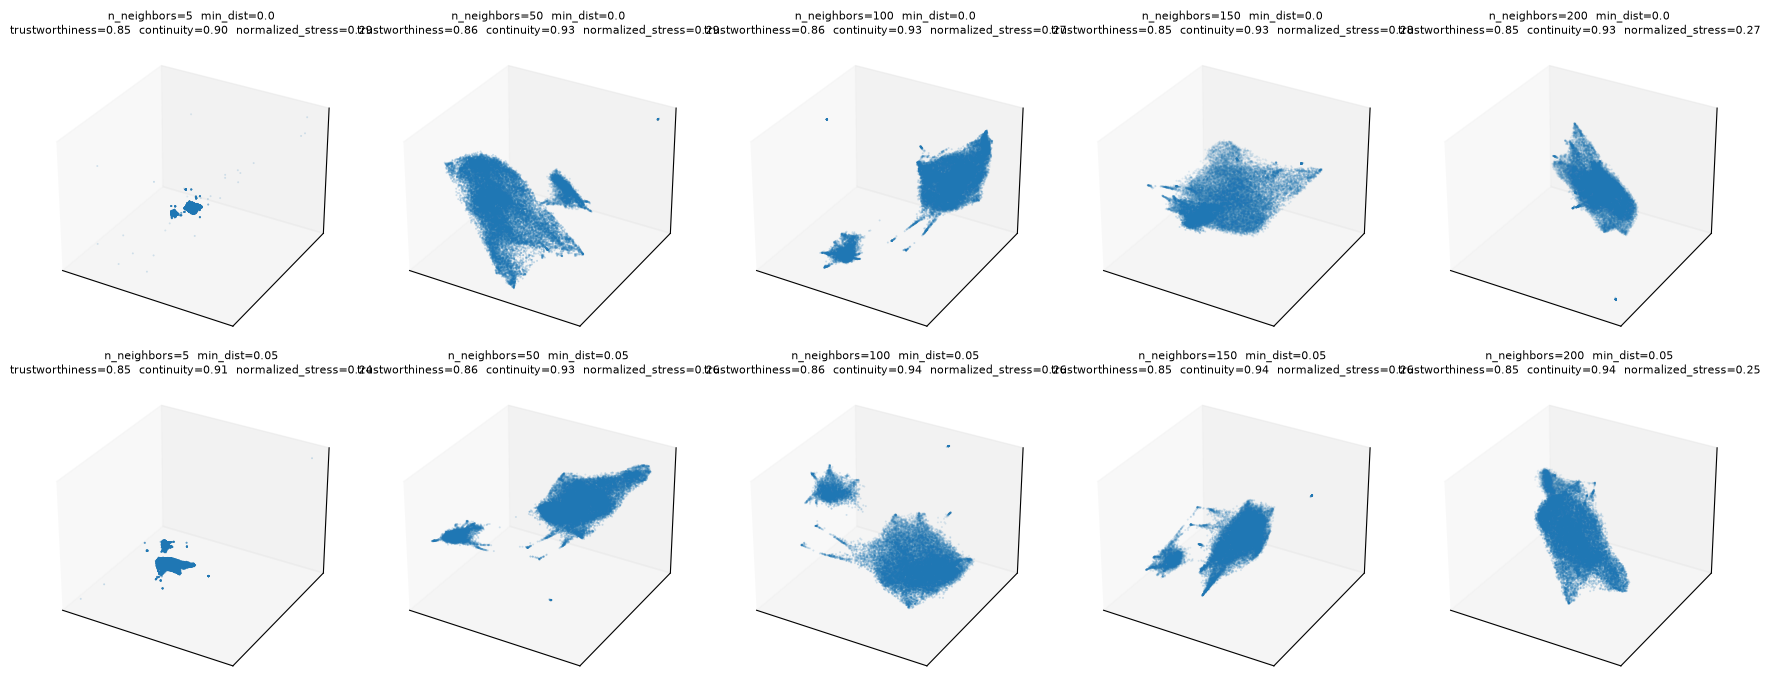

In [11]:
plot_embedding_grid(result, x="n_neighbors", y="min_dist", dims=3);

## Read the embedding

The sweep plots ask which configuration to keep.  These ask what the
kept one is organized by: same embedding, one panel per variable, so a
gradient across the cloud reads as a gradient.

The sweep stores a subsample of the rows it fitted, so anything used as
a color has to be indexed with `result.row_index` first — the plots
raise rather than silently misalign.

In [ ]:
from visualization.embedding_plots import (plot_embedding_by,
                                           plot_embedding_features)

best = result.table["trustworthiness"].idxmax()
E = result.embeddings[best]
print(result.table.loc[best, list(result.swept)].to_dict(), E.shape)

# centroid_lat was never selected as a feature, so it comes off the
# source table on X's rows, then down to the rows this embedding kept.
meta = ds.meta(raw.table, ["centroid_lat", "centroid_lon"]).iloc[result.row_index]

plot_embedding_by(E, meta["centroid_lat"].to_numpy(), name="centroid_lat");

A clean latitude gradient across the cloud means the embedding is a map
of where fronts are, not a taxonomy of what they are.  Most features
carry latitude — `Theta_mean` correlates with it at 0.95 — and
`div_by_f` only takes it out of the strain columns.

In [ ]:
PANELS = ["length_km", "gradb2_mean", "rossby_number_mean",
          "strain_mag_mean", "mean_curvature", "num_branches"]

# Unscaled values, so each colorbar reads in the variable's own units.
frame = pd.DataFrame(ds.raw, columns=ds.feature_names)[PANELS].iloc[result.row_index]
plot_embedding_features(E, frame, n_cols=3);

Color scales clip to the 2nd–98th percentile.  Front statistics are
heavy-tailed enough that the full range puts every point at one end.